In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
uniprotID_geneSymbol = pd.read_excel("D:/chh/2023workProject/prottalk/database/uniprotID_geneSymbol_geneID.xlsx")

In [ ]:
matrixB = pd.read_csv("D:/chh/2023workProject/prottalk/code/differ analysis20230822/matrix.csv", index_col= 0)
drug_cell_drugs = pd.read_excel("D:/chh/2023workProject/prottalk/database/drug_cell_inhi24_IC50_MOA_combo_20231113-1549.xlsx" )


In [12]:
sampleInfoB = pd.read_csv("D:/chh/2023workProject/prottalk/database/iDrug_sample_final_info20231207_NY.csv") 
sampleInfoB.head()

,Sample_ID,protein_plate,pert_id,pert_iname,pert_time,BioRep,NY
0,20rep,HCC1806,#72,Indocyanine,6,1,N
1,41rep,HCC1806,#72,Indocyanine,24,1,N
2,62rep,HCC1806,#72,Indocyanine,48,1,N
3,83rep,HCC38,#72,Indocyanine,6,1,N
4,104rep,HCC38,#72,Indocyanine,24,1,N


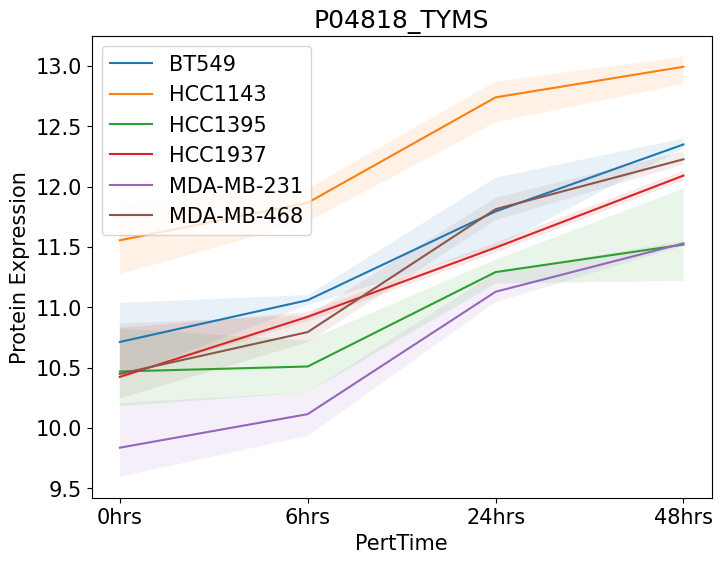

In [ ]:
sb = "kinase inhibitor"
proCur = "P04818"

plt.figure(figsize = (8, 6))
for i in ['BT549', 'HCC1143', 'HCC1395', 'HCC1937', 'MDA-MB-231','MDA-MB-468']:
    sample0  = list( set(sampleInfoB[(sampleInfoB["protein_plate"].isin([i]))  & (sampleInfoB["pert_time"] == 0)]["Sample_ID"] ) & set(matrixB.index.values)  ) 
    sample6  = list( set(sampleInfoB[(sampleInfoB["protein_plate"].isin([i]))  & (sampleInfoB["pert_time"] == 6) & (sampleInfoB['pert_id'] == '#69') ]["Sample_ID"] ) & set(matrixB.index.values)  ) 
    sample24  = list( set(sampleInfoB[(sampleInfoB["protein_plate"].isin([i])) & (sampleInfoB["pert_time"] == 24) & (sampleInfoB['pert_id'] == '#69')]["Sample_ID"] ) & set(matrixB.index.values)  ) 
    sample48  = list( set(sampleInfoB[(sampleInfoB["protein_plate"] .isin([i])) &  (sampleInfoB["pert_time"] == 48)& (sampleInfoB['pert_id'] == '#69')]["Sample_ID"] ) & set(matrixB.index.values)  ) 
    
    matrix0 = matrixB.loc[sample0, proCur ].dropna()

    matrix0 = matrixB.loc[sample0, proCur ].dropna()
    if matrix0.shape[0] == 0:
        matrix0 = np.array([0])
    matrix6 = matrixB.loc[sample6, proCur ].dropna()
    if matrix6.shape[0] == 0:
        matrix6 = np.array([0])
    matrix24 = matrixB.loc[sample24, proCur ].dropna()
    if matrix24.shape[0] == 0:
        matrix24 = np.array([0])
    matrix48 = matrixB.loc[sample48, proCur ].dropna()
    if matrix48.shape[0] == 0:
        matrix48 = np.array([0])
    y1 = [matrix0.mean() , matrix6.mean()   , matrix24.mean() , matrix48.mean()  ]
    y1 = [0 if np.isnan(val) else val for val in y1]
    x = list(range(1, 5, 1))
    plt.plot(x, y1, linestyle='-' , label= i) # , marker = "o"
    y2  = [ np.percentile(matrix0 , 75) , np.percentile(matrix6 , 75) , np.percentile(matrix24  , 75) , np.percentile(matrix48 , 75) ]
    y3  =  [ np.percentile(matrix0 , 25) , np.percentile(matrix6 , 25) , np.percentile(matrix24  , 25) , np.percentile(matrix48 , 25) ]
    plt.fill_between(x, y2, y3, alpha=0.1)
plt.xticks(x, ["0hrs", "6hrs", "24hrs", "48hrs"] )
plt.ylabel('Protein Expression')
plt.xlabel('PertTime')
plt.title( proCur + "_TYMS" )# 
plt.legend(loc  = "upper left") # 显示label
# plt.savefig("D:\chh\2023workProject\prottalk\code\differ analysis20230822\pert_id\cell\DrugTargetInSampleInfo_Anova_plot\20231130上下四分卫_Fluorouracil_TYMS.pdf", bbox_inches = 'tight')
plt.show()
plt.close()